# Lorenz '63 — Your First somax Simulation

The [Lorenz '63 system](https://en.wikipedia.org/wiki/Lorenz_system) is the
canonical low-dimensional chaotic attractor. It is the simplest model in
somax and a good starting point for understanding the API.

**What you'll learn:**

1. How to create a model, state, and run a forward simulation
2. How the `SomaxModel` contract works (`vector_field`, `integrate`, `diagnose`)
3. How to differentiate through a simulation with `jax.grad`
4. How to run an ensemble with `jax.vmap`

## Background

The system is defined by three coupled ODEs with parameters
$\sigma$ (Prandtl number), $\rho$ (Rayleigh number), and
$\beta$ (geometric factor):

$$
\frac{dx}{dt} = \sigma(y - x), \qquad
\frac{dy}{dt} = x(\rho - z) - y, \qquad
\frac{dz}{dt} = xy - \beta z
$$

At the standard parameters $(\sigma, \rho, \beta) = (10, 28, 8/3)$ the
system exhibits deterministic chaos: nearby trajectories diverge
exponentially, tracing the famous butterfly-shaped strange attractor.

In [1]:
from __future__ import annotations

import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt

from somax.models import L63State, Lorenz63

## 1. Create the model

`Lorenz63.create()` builds a model with the standard parameter values.
The model is an `eqx.Module` — an immutable pytree whose fields
(including `params`) are visible to `jax.grad` and `jax.jit`.

In [2]:
model = Lorenz63.create(sigma=10.0, rho=28.0, beta=8.0 / 3.0)
print(model)

Lorenz63(params=L63Params(sigma=weak_f32[], rho=weak_f32[], beta=weak_f32[]))


## 2. Forward simulation

`model.integrate()` wraps `diffrax.diffeqsolve` with automatic
boundary-condition enforcement. We save the trajectory at dense
output times to visualize the attractor.

In [3]:
state0 = L63State(x=jnp.array(1.0), y=jnp.array(1.0), z=jnp.array(1.0))

t0, t1, dt = 0.0, 40.0, 0.01
ts = jnp.arange(t0, t1, dt)

sol = model.integrate(
    state0,
    t0=t0,
    t1=t1,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts),
)

print(f"Trajectory shape: x={sol.ys.x.shape}, y={sol.ys.y.shape}, z={sol.ys.z.shape}")

Trajectory shape: x=(4000,), y=(4000,), z=(4000,)


## 3. Visualize the attractor

The classic 3D butterfly and the three time series.

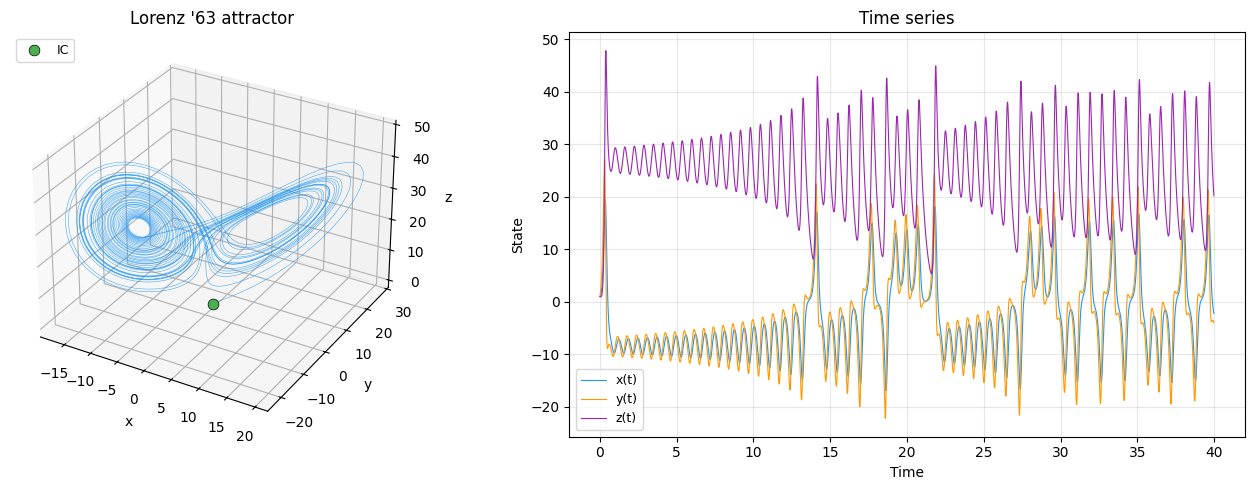

In [4]:
colors = {
    "trajectory": "#2196F3",
    "start": "#4CAF50",
    "x": "#2196F3",
    "y": "#FF9800",
    "z": "#9C27B0",
}

fig = plt.figure(figsize=(14, 5))

# --- 3D attractor ---
ax3d = fig.add_subplot(121, projection="3d")
ax3d.plot(
    sol.ys.x,
    sol.ys.y,
    sol.ys.z,
    lw=0.4,
    alpha=0.8,
    color=colors["trajectory"],
)
ax3d.scatter(
    [sol.ys.x[0]],
    [sol.ys.y[0]],
    [sol.ys.z[0]],
    s=60,
    c=colors["start"],
    edgecolors="k",
    linewidths=0.5,
    zorder=5,
    label="IC",
)
ax3d.set_xlabel("x")
ax3d.set_ylabel("y")
ax3d.set_zlabel("z")
ax3d.set_title("Lorenz '63 attractor")
ax3d.legend(loc="upper left", fontsize=9)

# --- Time series ---
ax_ts = fig.add_subplot(122)
ax_ts.plot(ts, sol.ys.x, lw=0.8, color=colors["x"], label="x(t)")
ax_ts.plot(ts, sol.ys.y, lw=0.8, color=colors["y"], label="y(t)")
ax_ts.plot(ts, sol.ys.z, lw=0.8, color=colors["z"], label="z(t)")
ax_ts.set_xlabel("Time")
ax_ts.set_ylabel("State")
ax_ts.set_title("Time series")
ax_ts.legend(fontsize=9)
ax_ts.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Diagnostics

`model.diagnose()` computes on-demand quantities from the state.
For L63 it returns the kinetic energy $E = \tfrac{1}{2}(x^2 + y^2 + z^2)$.

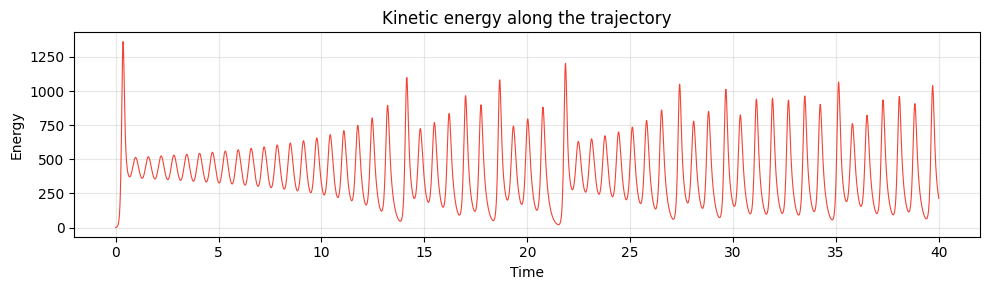

In [5]:
energy = jax.vmap(model.diagnose)(sol.ys).energy

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ts, energy, lw=0.8, color="#F44336")
ax.set_xlabel("Time")
ax.set_ylabel("Energy")
ax.set_title("Kinetic energy along the trajectory")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Adjoint methods for differentiation

Differentiating through an ODE solve requires an **adjoint method**
that trades off memory, accuracy, and speed. diffrax provides three:

| Adjoint | Memory | Gradients | Use case |
|---------|--------|-----------|----------|
| `RecursiveCheckpointAdjoint` | $O(\sqrt{N})$ | Exact | **Default** |
| `DirectAdjoint` | $O(N)$ | Exact | Short windows |
| `BacksolveAdjoint` | $O(1)$ | Approx | Long windows |
| `ImplicitAdjoint` | $O(1)$ | Exact | Steady states |

- **`RecursiveCheckpointAdjoint`** (the default) uses
  Griewank--Walther optimal checkpointing: it re-computes forward
  steps from saved checkpoints during the backward pass, giving
  exact gradients with sub-linear memory.
- **`DirectAdjoint`** stores the entire forward trajectory —
  exact but $O(N)$ memory. Also supports forward-mode AD.
- **`BacksolveAdjoint`** solves the continuous adjoint ODE
  backwards in time with $O(1)$ memory. Gradients are approximate
  (optimize-then-discretize $\neq$ discretize-then-optimize).
- **`ImplicitAdjoint`** differentiates through the implicit
  function theorem: if the solver finds a fixed point $u^*$ such
  that $g(u^*, \theta) = 0$, the gradient is
  $du^*/d\theta = -(dg/du)^{-1}\, dg/d\theta$. Memory is $O(1)$
  and gradients are exact, but only applies to steady-state /
  fixed-point problems (not time-stepping).

### 5a. Gradient with respect to parameters

**Use case: parameter estimation.** Given observations, find the
parameters $\theta = (\sigma, \rho, \beta)$ that minimize a loss.

We compute $\nabla_\theta \mathcal{L}$ where
$\mathcal{L} = \sum_t \| \mathbf{u}(t) \|^2$ and the state
$\mathbf{u}(t)$ depends on $\theta$ through the ODE:

$$
\frac{\partial \mathcal{L}}{\partial \theta}
= \int_0^T \lambda(t)^\top
  \frac{\partial f}{\partial \theta}\, dt
$$

where $\lambda(t)$ is the adjoint state satisfying the backward ODE
$\dot{\lambda} = -(\partial f / \partial u)^\top \lambda$.

In [6]:
state0_grad = L63State(x=jnp.array(1.0), y=jnp.array(1.0), z=jnp.array(1.0))


@eqx.filter_grad
def grad_params(model):
    sol = model.integrate(state0_grad, t0=0.0, t1=1.0, dt=0.01)
    return jnp.sum(sol.ys.x**2 + sol.ys.y**2 + sol.ys.z**2)


grads_theta = grad_params(model)

print("--- Gradient w.r.t. parameters ---")
print(f"  dL/d(sigma) = {grads_theta.params.sigma:.4f}")
print(f"  dL/d(rho)   = {grads_theta.params.rho:.4f}")
print(f"  dL/d(beta)  = {grads_theta.params.beta:.4f}")

--- Gradient w.r.t. parameters ---
  dL/d(sigma) = -2.7039
  dL/d(rho)   = 15.1506
  dL/d(beta)  = 331.9404


### 5b. Gradient with respect to the initial state

**Use case: state estimation / data assimilation.** Given a model
with known parameters, find the initial condition $\mathbf{u}_0$
that best fits observations (the 4D-Var problem).

We compute $\nabla_{\mathbf{u}_0} \mathcal{L}$:

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{u}_0}
= \lambda(0)
$$

where $\lambda(t)$ is the same adjoint state, but now evaluated
at $t = 0$. This is the gradient that 4D-Var minimizes.

In [7]:


def loss_state(state0):
    sol = model.integrate(state0, t0=0.0, t1=1.0, dt=0.01)
    return jnp.sum(sol.ys.x**2 + sol.ys.y**2 + sol.ys.z**2)


grads_u0 = jax.grad(loss_state)(state0_grad)

print("--- Gradient w.r.t. initial state ---")
print(f"  dL/d(x0) = {grads_u0.x:.4f}")
print(f"  dL/d(y0) = {grads_u0.y:.4f}")
print(f"  dL/d(z0) = {grads_u0.z:.4f}")

--- Gradient w.r.t. initial state ---
  dL/d(x0) = -21.0361
  dL/d(y0) = -18.2364
  dL/d(z0) = 39.6907


### 5c. Joint gradient — parameters and state

**Use case: bi-level optimization.** Simultaneously estimate the
initial state and model parameters (e.g. weak-constraint 4D-Var).

We compute $(\nabla_{\mathbf{u}_0} \mathcal{L}$,$\nabla_\theta \mathcal{L})$ in a single backward pass using
`eqx.partition` to separate the differentiable leaves.

In [8]:


def loss_joint(state0, model):
    sol = model.integrate(state0, t0=0.0, t1=1.0, dt=0.01)
    return jnp.sum(sol.ys.x**2 + sol.ys.y**2 + sol.ys.z**2)


grads_u0_joint, grads_model_joint = jax.grad(loss_joint, argnums=(0, 1))(
    state0_grad, model
)

print("--- Joint gradient ---")
print(f"  dL/d(x0)    = {grads_u0_joint.x:.4f}")
print(f"  dL/d(y0)    = {grads_u0_joint.y:.4f}")
print(f"  dL/d(z0)    = {grads_u0_joint.z:.4f}")
print(f"  dL/d(sigma) = {grads_model_joint.params.sigma:.4f}")
print(f"  dL/d(rho)   = {grads_model_joint.params.rho:.4f}")
print(f"  dL/d(beta)  = {grads_model_joint.params.beta:.4f}")

--- Joint gradient ---
  dL/d(x0)    = -21.0361
  dL/d(y0)    = -18.2364
  dL/d(z0)    = 39.6907
  dL/d(sigma) = -2.7039
  dL/d(rho)   = 15.1506
  dL/d(beta)  = 331.9404


### 5d. Comparing adjoint methods

We time `RecursiveCheckpointAdjoint` (default) vs `DirectAdjoint`
on the same problem. `BacksolveAdjoint` requires passing the model
as an explicit argument to `diffeqsolve` (not via closure), so it
needs a different API pattern — see the
[diffrax docs](https://docs.kidger.site/diffrax/api/adjoints/)
for details.

In [9]:
import time


def timed_grad(adjoint, label):
    @eqx.filter_grad
    def fn(model):
        sol = model.integrate(state0_grad, t0=0.0, t1=1.0, dt=0.01, adjoint=adjoint)
        return jnp.sum(sol.ys.x**2 + sol.ys.y**2 + sol.ys.z**2)

    # Warm-up (JIT compilation)
    g = fn(model)
    jax.block_until_ready(g.params.sigma)
    # Timed run
    t_start = time.perf_counter()
    g = fn(model)
    jax.block_until_ready(g.params.sigma)
    elapsed = time.perf_counter() - t_start
    print(f"  {label:35s}  dL/d(sigma)={g.params.sigma:.4f}  ({elapsed:.4f}s)")


print("--- Adjoint method comparison ---")
timed_grad(dfx.RecursiveCheckpointAdjoint(), "RecursiveCheckpoint")
timed_grad(dfx.DirectAdjoint(), "Direct")

--- Adjoint method comparison ---


  RecursiveCheckpoint                  dL/d(sigma)=-2.7039  (5.1276s)


  Direct                               dL/d(sigma)=-2.7036  (3.1110s)


## 6. Ensemble simulation with `jax.vmap`

Chaotic systems are sensitive to initial conditions. We can explore
this by running an ensemble of trajectories with small perturbations
and watching them diverge.

In [10]:
n_ensemble = 50
key = jrandom.PRNGKey(42)
perturbations = 0.01 * jrandom.normal(key, shape=(n_ensemble, 3))

ensemble_states = L63State(
    x=1.0 + perturbations[:, 0],
    y=1.0 + perturbations[:, 1],
    z=1.0 + perturbations[:, 2],
)

ts_ens = jnp.arange(0.0, 30.0, 0.01)


def integrate_one(state0):
    return model.integrate(
        state0,
        t0=0.0,
        t1=30.0,
        dt=0.01,
        saveat=dfx.SaveAt(ts=ts_ens),
    )


ensemble_sol = eqx.filter_vmap(integrate_one)(ensemble_states)

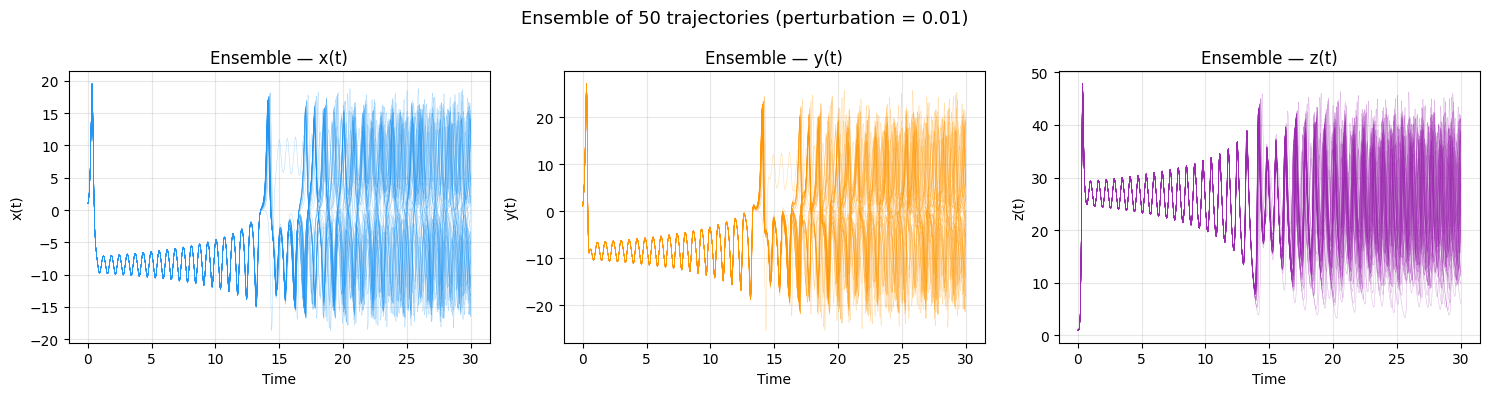

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, var, name, color in zip(
    axes,
    [ensemble_sol.ys.x, ensemble_sol.ys.y, ensemble_sol.ys.z],
    ["x(t)", "y(t)", "z(t)"],
    [colors["x"], colors["y"], colors["z"]],
    strict=True,
):
    for j in range(n_ensemble):
        ax.plot(ts_ens, var[j], lw=0.3, alpha=0.4, color=color)
    ax.set_xlabel("Time")
    ax.set_ylabel(name)
    ax.set_title(f"Ensemble — {name}")
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Ensemble of {n_ensemble} trajectories (perturbation = 0.01)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## Summary

| Concept | somax API |
|---------|-----------|
| Create a model | `Lorenz63.create(sigma=10, rho=28, beta=8/3)` |
| Initial condition | `L63State(x=..., y=..., z=...)` |
| Forward simulation | `model.integrate(state0, t0, t1, dt, saveat=...)` |
| Diagnostics | `model.diagnose(state)` |
| Grad w.r.t. params | `eqx.filter_grad(loss)(model)` |
| Grad w.r.t. state | `jax.grad(loss)(state0)` |
| Joint grad | `jax.grad(loss, argnums=(0, 1))(state0, model)` |
| Ensemble | `eqx.filter_vmap(integrate_one)(batch_states)` |

**Next steps:**

- Try the [Lorenz '96](lorenz96_simulation) tutorial for a
  higher-dimensional chaotic system
- Explore the [Shallow Water Model](swm_simulation) for your first PDE simulation